<h1>TSP</h1>

In [184]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.animation as animation
import os

### 1. Generacja przestrzeni problemu

Najpierw zdefiniowałem funkcje odpowiedzialne za wygenerowanie chmury $n$ punktów w przestrzeni dwuwymiarowej. Przygotowałem trzy różne warianty rozkładów przestrzennych:

*   **Rozkład jednostajny:** Punkty są losowane równomiernie na całym dostępnym obszarze.
*   **Rozkład normalny – 4 grupy:** Punkty skupiają się wokół czterech oddalonych od siebie centrów.
*   **Dziewięć odseparowanych grup:** Zdefiniowano 9 równomiernie rozmieszczonych centrów i zastosowano rozkład normalny z niewielkim odchyleniem standardowym.




In [80]:
def generate_uniform_cities(num_cities):
    coords = np.random.uniform(low=0, high=100, size=(num_cities, 2))
    return [(x, y) for [x, y] in coords]


def generate_normal_4_groups(num_cities):
    centers = [(x, y) for x in [25, 75] for y in [25, 75]]
    
    scales = [4.0, 4.0, 4.0, 4.0] 
    
    cities = []
    
    counts = [num_cities // 4] * 4
    counts[-1] += num_cities % 4 
    
    for i in range(4):
        group_coords = np.random.normal(loc=centers[i], scale=scales[i], size=(counts[i], 2))
        cities.extend([(x, y) for x, y in group_coords])
        
    np.random.shuffle(cities)
    
    return cities


def generate_separated_9_groups(num_cities):
    centers = [(x, y) for x in [15, 50, 85] for y in [15, 50, 85]]
    
    scale = 2.5 
    
    cities = []
    
    counts = [num_cities // 9] * 9
    counts[-1] += num_cities % 9 
    
    for i in range(9):
        group_coords = np.random.normal(loc=centers[i], scale=scale, size=(counts[i], 2))
        cities.extend([(x, y) for x, y in group_coords])
        
    np.random.shuffle(cities)
    
    return cities

### 2. Wizualizacja trasy

Następnie przygotowałem funkcję do wizualizacji układu punktów oraz samej trasy. Tutaj celowo nie łączę pierwszego i ostatniego miasta.

In [81]:
def visualize_tsp(cities, ax, route=None):
    x_coords = [city[0] for city in cities]
    y_coords = [city[1] for city in cities]
    
    ax.scatter(x_coords, y_coords, color='red', s=50, zorder=5, label='Cities')

    if route is not None:
        
        segments = []
        for i in range(len(route) - 1):
            start_city = cities[route[i]]
            end_city = cities[route[i + 1]]
            segments.append((start_city, end_city))


        color_indices = np.linspace(0, 1, len(segments))        
        cmap = plt.get_cmap('cool')
        
        lc = LineCollection(segments, cmap=cmap, linewidth=2.0, zorder=4, alpha=0.9)
        lc.set_array(np.array(color_indices)) 
        
        ax.add_collection(lc)
        

    ax.set_xlabel("X Coordinate")
    ax.set_ylabel("Y Coordinate")
    ax.grid(True, linestyle='--', alpha=0.5)
    


### 3. Wykresy energii oraz temperatury

In [82]:
def visualize_best_energy_and_temp(best_energies, temperatures, ax1):
    iterations = range(len(best_energies))

    ax1.set_xlabel('Number of Iterations', fontsize=12)
    ax1.set_ylabel('Best Energy (Total Distance)', color='red', fontsize=12)
    
    ax1.plot(iterations, best_energies, color='red', label='Best Energy', linewidth=2.5)
    ax1.tick_params(axis='y', labelcolor='red')
    ax1.grid(True, linestyle='--', alpha=0.5)


    ax2 = ax1.twinx()  
    ax2.set_ylabel('Current Temperature', color='orange', fontsize=12)
    
    ax2.plot(iterations, temperatures, color='orange', label='Temperature', linestyle='--', linewidth=2.5)
    ax2.tick_params(axis='y', labelcolor='orange')

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right', fontsize=11)


### 3. Wykresy energii oraz temperatury i trasa razem

In [83]:
def show_side_by_side(cities, route, best_energies, temperatures, label):
    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(16, 7))
    
    visualize_tsp(cities, ax=ax_left, route=route)
    visualize_best_energy_and_temp(best_energies, temperatures, ax1=ax_right)
    

    fig.suptitle(label, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

<h5>Funkcji pomocniczy do obliczania długości</h5>

In [84]:
#wyliczamy odległość
def distance(city1, city2):
    return math.sqrt((city1[0] - city2[0])**2 + (city1[1] - city2[1])**2)

In [85]:
#wyliczamy całą drogę 
def total_path_distance(route, cities):
    total_dist = 0.0
    num_cities = len(route)
    for i in range(num_cities):
        current_city = cities[route[i]]

        next_city = cities[route[(i + 1) % num_cities]]
        total_dist += distance(current_city, next_city)
    return total_dist

### 4. Generowanie sąsiedniego rozwiązania


*   **Arbitrary swap (średnie):** Wybieramy dwa całkowicie losowe miasta na naszej trasie i po prostu zamieniamy je miejscami.
*   **Consecutive swap (gorsze):** Losujemy jedno miasto i zamieniamy je z jego bezpośrednim sąsiadem na liście.
*   **Reversed swap (lepsze):** Dodatkowo zaimplementowałem mechanizm, który wybiera dwa punkty cięcia na trasie i odwraca kolejność wszystkich miast pomiędzy nimi.

In [86]:
def apply_arbitary_swap(route):
    new_route = route.copy()

    i, j = random.sample(range(len(route)), 2)

    new_route[i], new_route[j] = new_route[j], new_route[i]
    return new_route


def apply_consecutive_swap(route):
    new_route = route.copy()
    
    i = random.randint(0, len(new_route)-1)    
    j = (i+1) % len(new_route)

    new_route[i], new_route[j] = new_route[j], new_route[i]

    
    return new_route

def apply_reversed_swap(route):
    new_route = route.copy()
    
    i, j = random.sample(range(len(route)), 2)
    if i > j: i, j = j, i
        
    new_route[i:j+1] = reversed(new_route[i:j+1])
    
    return new_route

### 5. Temperatura

* **Chłodzenie wykładnicze (temp_exp):** Zapewnia szybki spadek na początku i łagodniejsze chłodzenie pod koniec.

* **Chłodzenie logarytmiczne (temp_log):** Temperatura spada tutaj bardzo powoli. Daje to największe szanse na znalezienie globalnego minimum, ale wymaga potężnej liczby iteracji.


In [ ]:
def temp_exp(par, itr, temp): return temp * (par ** itr)

def temp_log(par, itr, temp): return temp / math.log(2+itr)

### 6. Funkcja gółwna

Główna idea jest taka:
* Jeśli nowa ścieżka jest krótsza (lepsza), akceptujemy ją od razu. 
* Jeśli jednak jest dłuższa, nadal mamy szansę ją przyjąć! 


In [148]:
def simulated_annealing_tsp(cities, temp, max_iterations, cooling_rate, swap_func, init_temp):
    n = len(cities)
    route_history = []
    
    current_route = list(range(n))
    current_distance = total_path_distance(current_route, cities)
    
    best_route = current_route.copy()
    best_distance = current_distance
    

    distancies = [best_distance]
    temperatures = [init_temp]
    for iteration in range(max_iterations):
        
        current_temp = temp(cooling_rate, iteration, init_temp)
        
            
        new_route = swap_func(current_route)
        new_distance = total_path_distance(new_route, cities)
        
        distance_diff = new_distance - current_distance
        
        if distance_diff < 0:
            current_route = new_route
            current_distance = new_distance

        elif random.random() < math.exp(-distance_diff / max(current_temp, 1e-10)):
            current_route = new_route
            current_distance = new_distance
                
        if current_distance < best_distance:                
            best_route = current_route.copy()
            best_distance = current_distance
        
        if iteration % 100 == 0 or iteration == max_iterations - 1:
            route_history.append(best_route.copy())
        distancies.append(current_distance)
        temperatures.append(current_temp)

            
    return best_route, best_distance, distancies, temperatures, route_history


### 7. Przeprowadzenie eksperymentów i analiza wyników


Najpierw testuje rózne n oraz układy

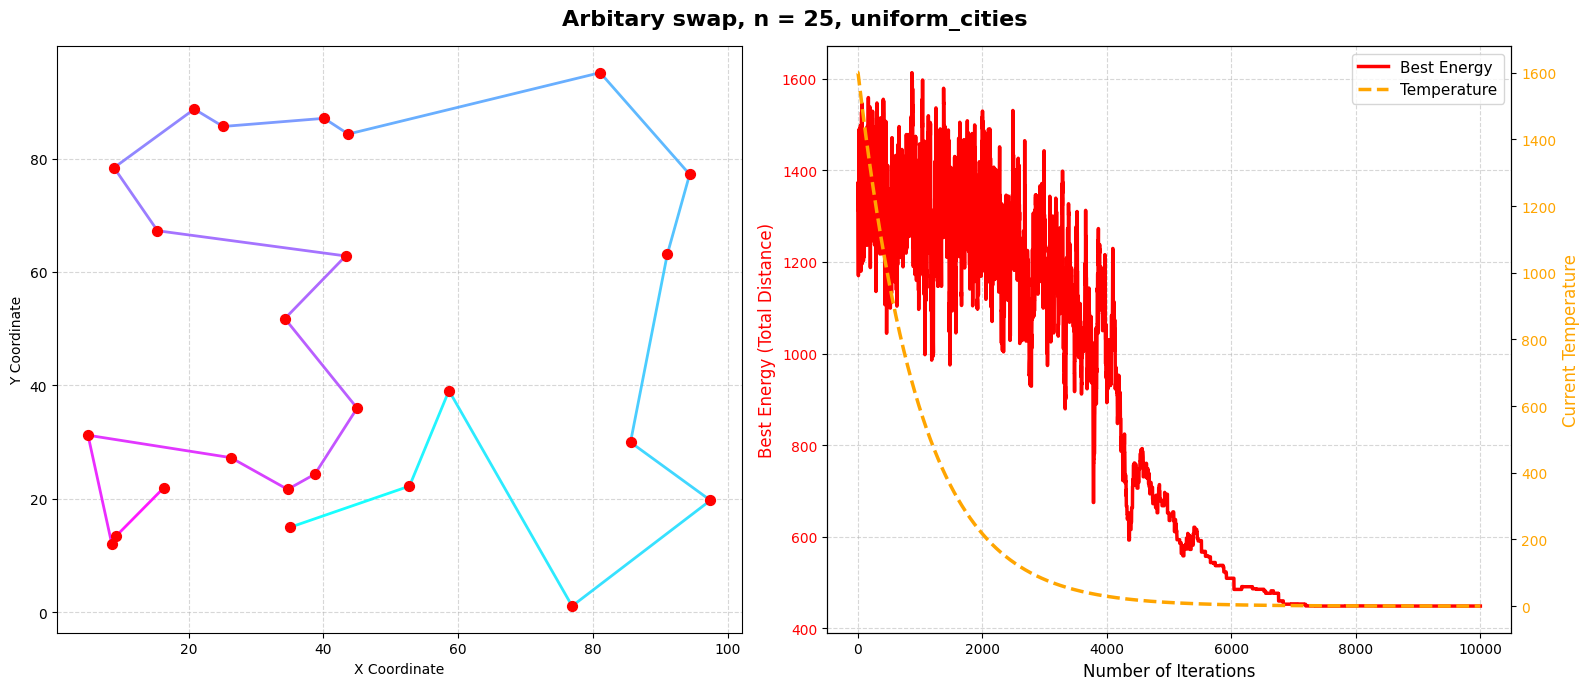

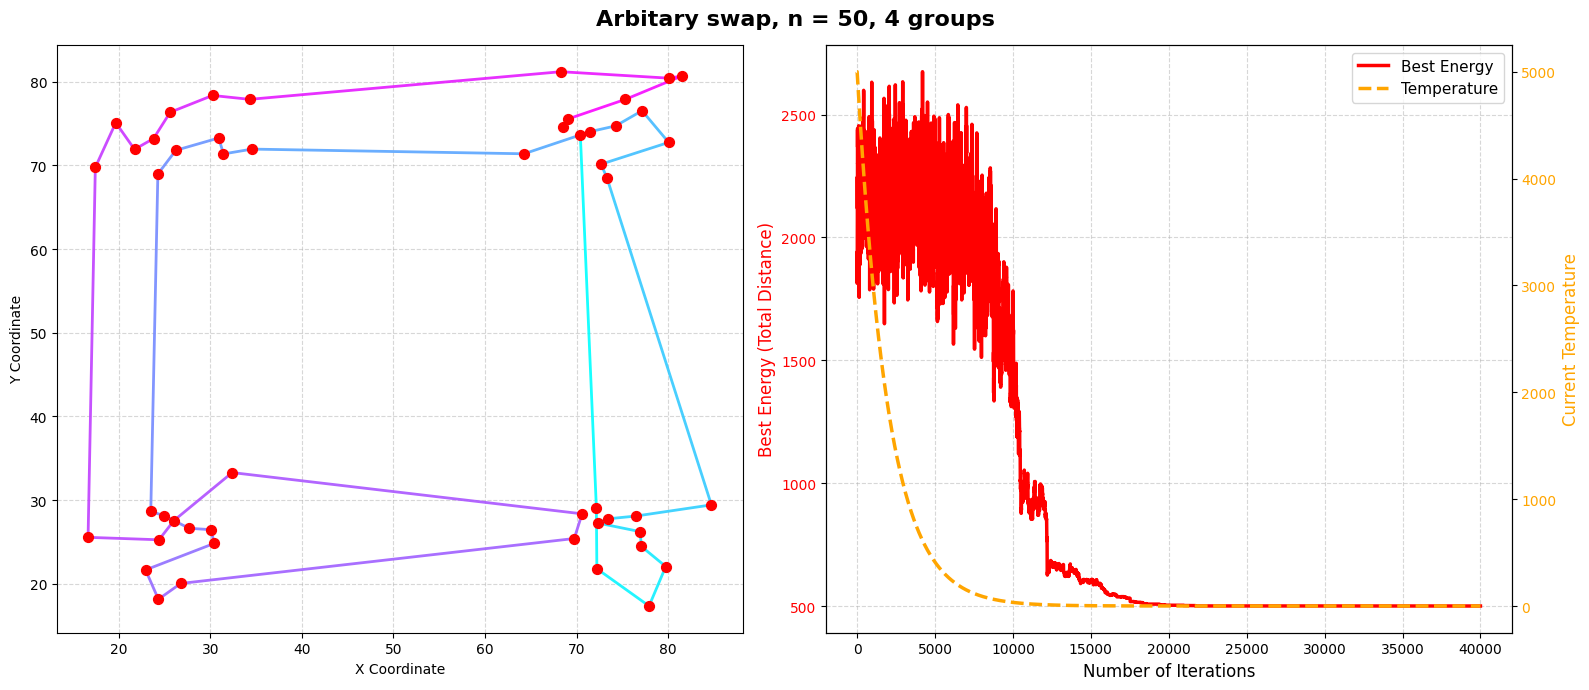

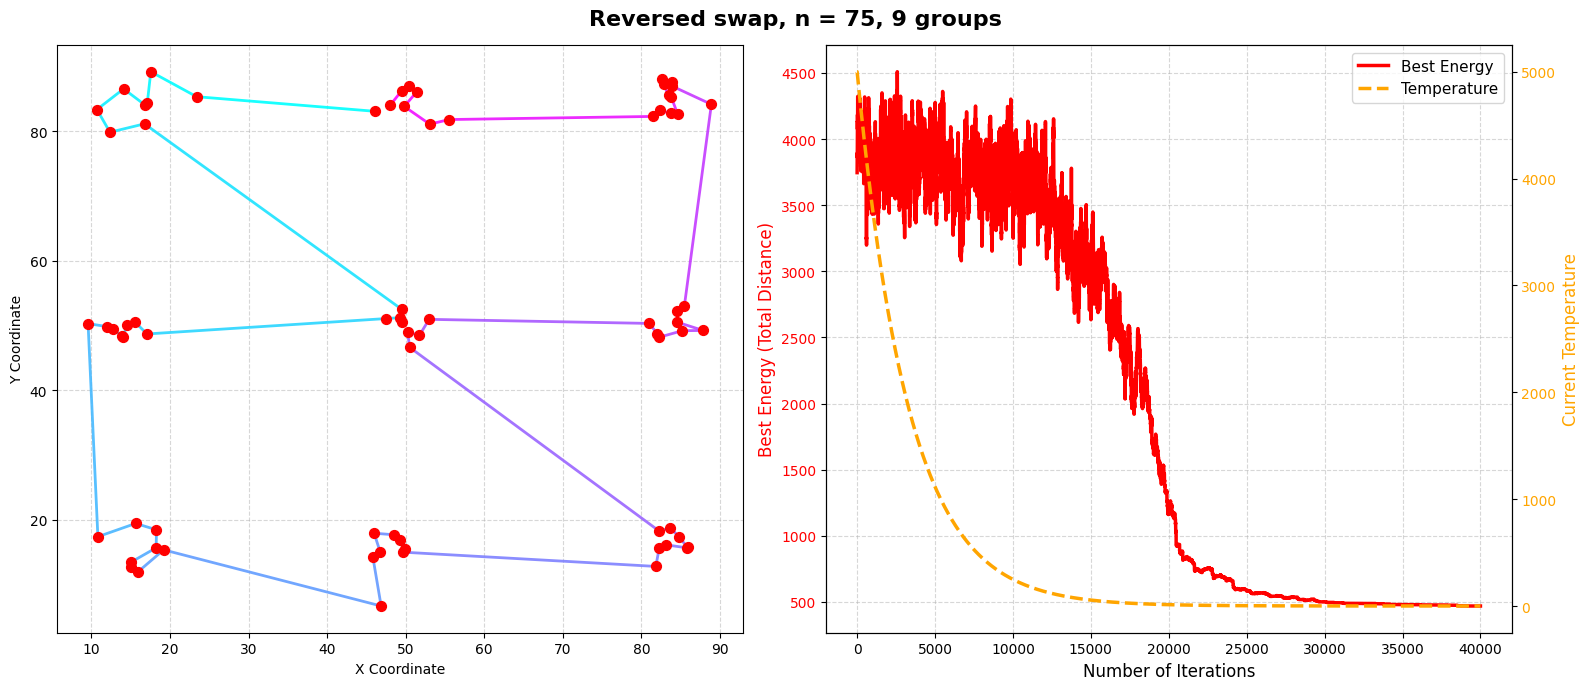

In [123]:

cities = generate_uniform_cities(25)
best_route, best_dist, dists, temps, history = simulated_annealing_tsp(
    cities, 
    temp=temp_exp, 
    max_iterations=10000, 
    cooling_rate=0.999, 
    swap_func=apply_arbitary_swap,
    init_temp=1600
)
show_side_by_side(cities, best_route, dists, temps, label = "Arbitary swap, n = 25, uniform_cities")

cities = generate_normal_4_groups(50)

best_route, best_dist, dists, temps, history = simulated_annealing_tsp(
    cities, 
    temp=temp_exp, 
    max_iterations=40000, 
    cooling_rate=0.9995, 
    swap_func=apply_arbitary_swap,
    init_temp=5000
)

show_side_by_side(cities, best_route, dists, temps, label = "Arbitary swap, n = 50, 4 groups")

cities = generate_separated_9_groups(75)

best_route, best_dist, dists, temps, history = simulated_annealing_tsp(
    cities, 
    temp=temp_exp, 
    max_iterations=40000, 
    cooling_rate=0.9997, 
    swap_func=apply_reversed_swap,
    init_temp=5000
)

show_side_by_side(cities, best_route, dists, temps, label = "Reversed swap, n = 75, 9 groups")



### 8. Testowanie pływu sposobu generacji sąsiedniego stanu


Już na poprzedniem przykładzie było widać jak bardzo się różni wynik w zależności od posobu generacji sąsiedniego stanu, teraz sprawdźmy to dokładniej

 Cała droga: 530.1695380453041


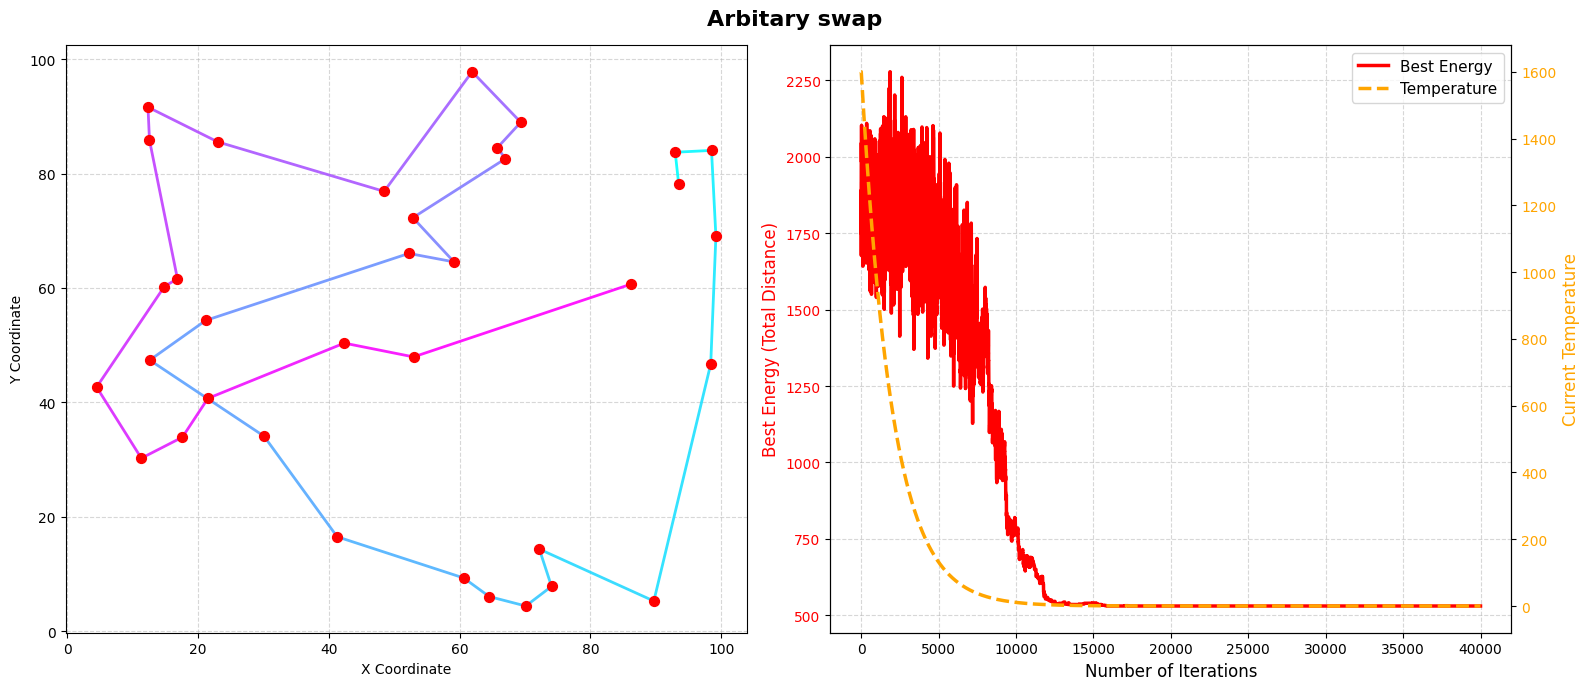

 Cała droga: 1047.6736500908025


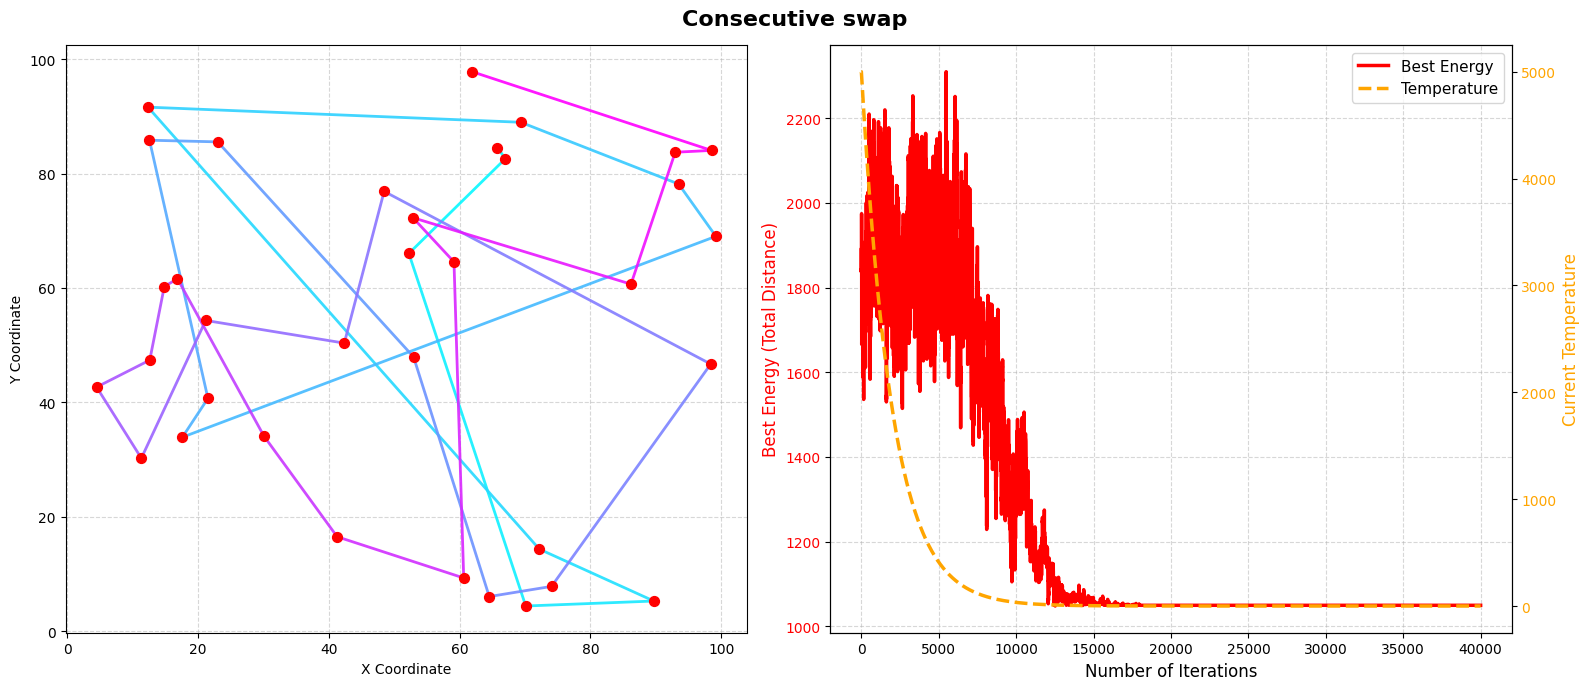

 Cała droga: 458.5136432891104


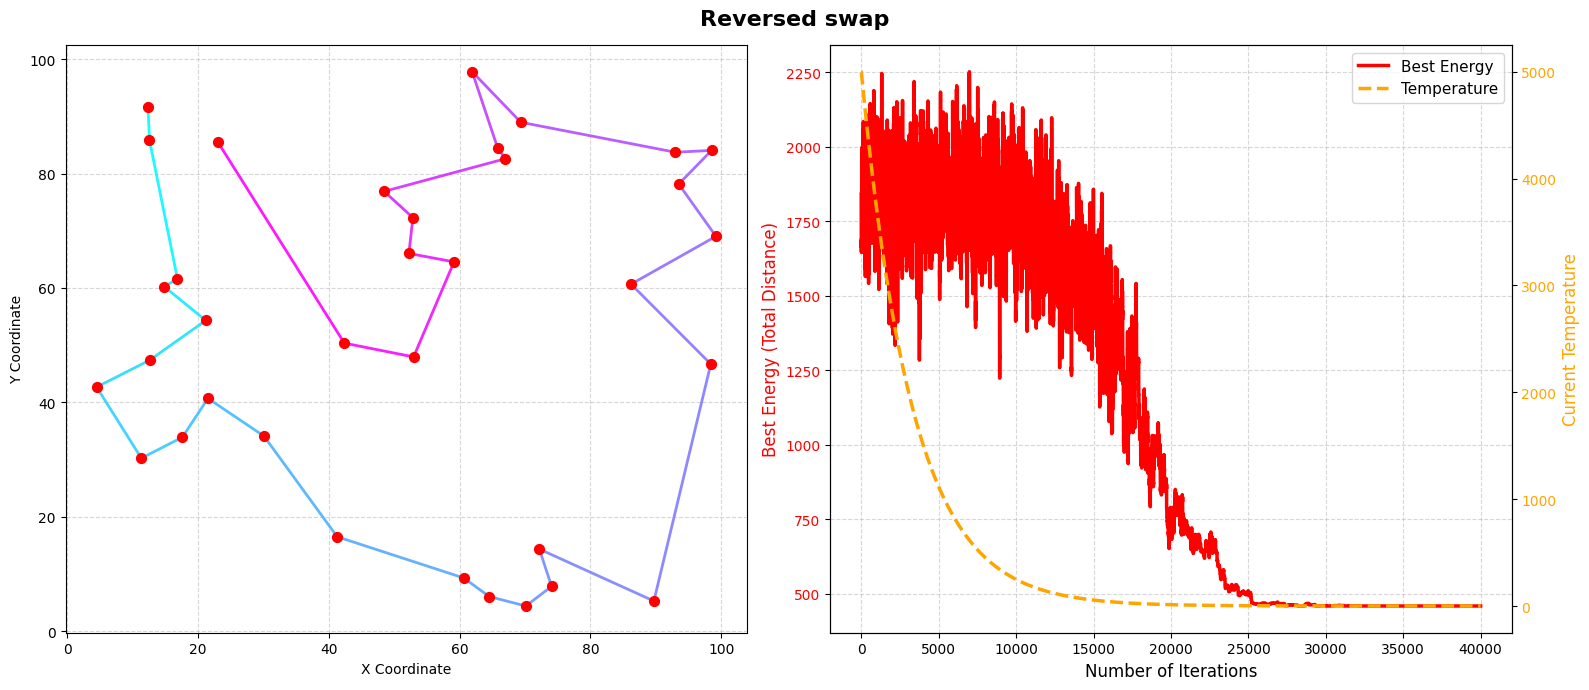

In [132]:
cities = generate_uniform_cities(35)
best_route, best_dist, dists, temps, history = simulated_annealing_tsp(
    cities, 
    temp=temp_exp, 
    max_iterations=40000, 
    cooling_rate=0.9995, 
    swap_func=apply_arbitary_swap,
    init_temp=1600
)
print(f" Cała droga: {best_dist}")
show_side_by_side(cities, best_route, dists, temps, label = "Arbitary swap")


best_route, best_dist, dists, temps, history = simulated_annealing_tsp(
    cities, 
    temp=temp_exp, 
    max_iterations=40000, 
    cooling_rate=0.9995, 
    swap_func=apply_consecutive_swap,
    init_temp=5000
)

print(f" Cała droga: {best_dist}")
show_side_by_side(cities, best_route, dists, temps, label = "Consecutive swap")


best_route, best_dist, dists, temps, history = simulated_annealing_tsp(
    cities, 
    temp=temp_exp, 
    max_iterations=40000, 
    cooling_rate=0.9997, 
    swap_func=apply_reversed_swap,
    init_temp=5000
)

print(f" Cała droga: {best_dist}")
show_side_by_side(cities, best_route, dists, temps, label = "Reversed swap")


*   **Consecutive swap (Najsłabszy):** Zamiana miejscami tylko dwóch sąsiadujących miast na liście wprowadza minimalną zmianę do trasy. Jeśli optymalne rozwiązanie wymaga przeniesienia miasta z początku trasy na jej koniec, algorytm musi wykonać serię wielu precyzyjnych zamian sąsiednich, co jest mało prawdopodobne. Przestrzeń poszukiwań przeszukiwana jest zbyt wolno, a algorytm łatwo "utyka" w lokalnych minimach.
*   **Arbitrary swap (Średni):** Zamiana dwóch losowych miast pozwala na drastyczne i dalekie skoki, co pomaga uciec z minimów lokalnych. Jest to jednak operacja bardzo "destrukcyjna". Taka zamiana zrywa aż cztery istniejące krawędzie na trasie i tworzy cztery nowe. Przez to algorytm często psuje dobre, krótkie fragmenty ścieżki, które zdążył już ułożyć, co spowalnia ostateczne "wygładzanie" trasy.
*   **Reversed swap (Najlepszy):** Odwrócenie fragmentu trasy zrywa tylko dwie krawędzie i zastępuje je dwiema nowymi, zachowując nienaruszoną kolejność odwiedzania miast wewnątrz odwracanego fragmentu. 

### 9. Analiza wpływu funkcji zmiany temperatury 

Ostatnim badanym elementem był wpływ schematu chłodzenia na proces zbieżności. W algorytmie symulowanego wyżarzania to właśnie od temperatury zależy, z jakim prawdopodobieństwem akceptujemy gorsze trasy:

*   **Chłodzenie wykładnicze (Exponential):** Temperatura spada tu dość szybko na początku , a potem jej spadek spowalnia.
*   **Chłodzenie logarytmiczne (Logarithmic):** Temperatura spada tutaj tak ekstremalnie wolno, że algorytm przez cały czas trwania pozostaje "gorący". 

 Cała droga: 450.5909104128629


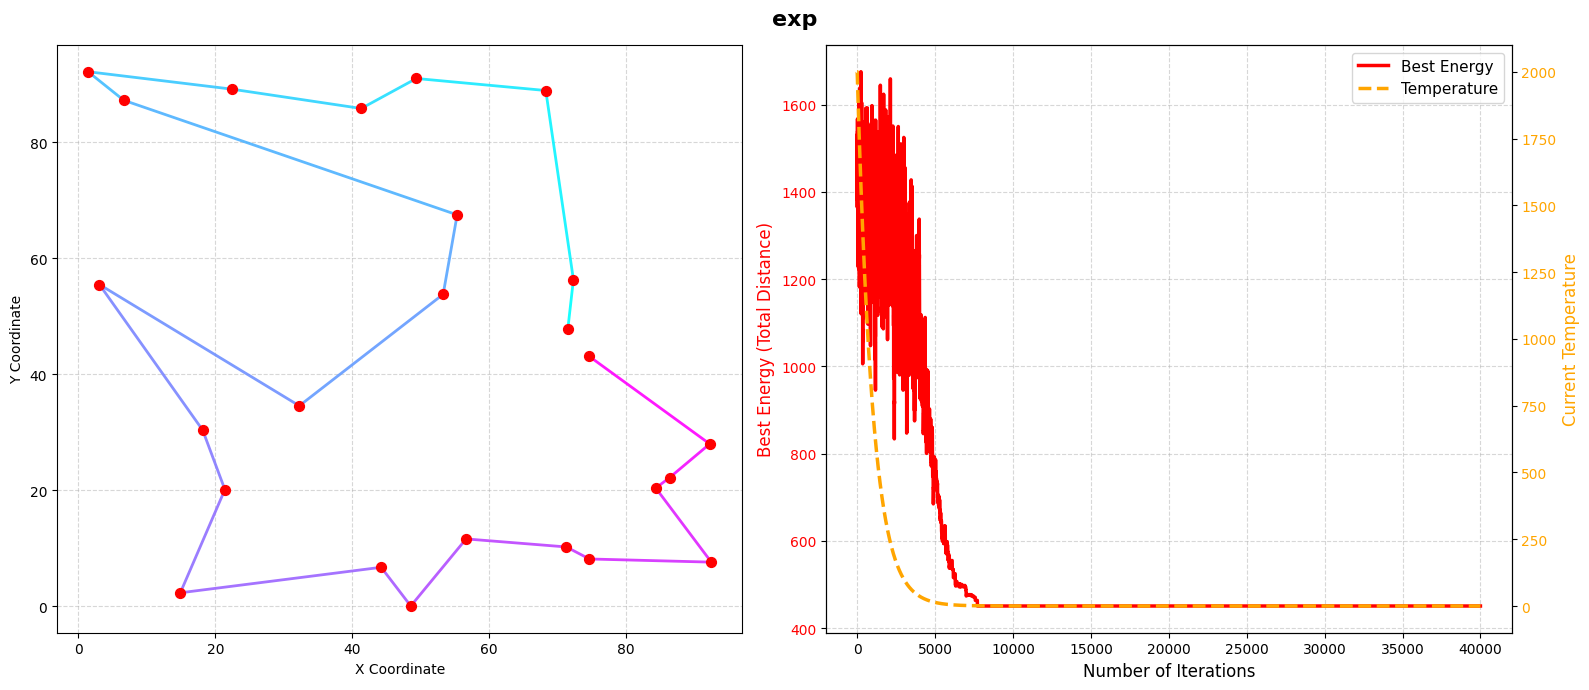

 Cała droga: 883.3069099253171


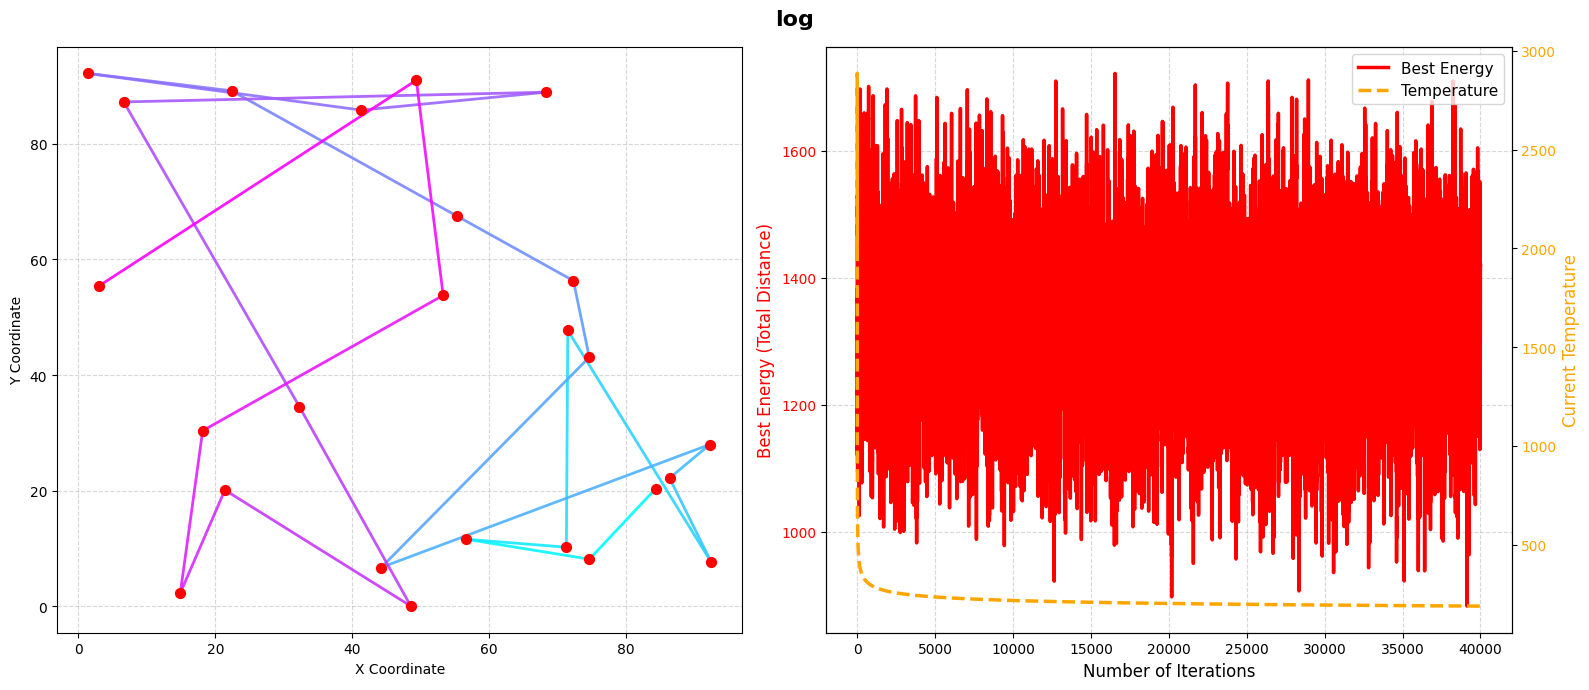

In [141]:

cities = generate_uniform_cities(25)
best_route, best_dist, dists, temps, history = simulated_annealing_tsp(
    cities, 
    temp=temp_exp, 
    max_iterations=40000, 
    cooling_rate=0.999, 
    swap_func=apply_arbitary_swap,
    init_temp=2000
)

print(f" Cała droga: {best_dist}")
show_side_by_side(cities, best_route, dists, temps, label = "exp")

best_route, best_dist, dists, temps, history = simulated_annealing_tsp(
    cities, 
    temp=temp_log, 
    max_iterations=40000, 
    cooling_rate=0.1, 
    swap_func=apply_arbitary_swap,
    init_temp=2000
)

print(f" Cała droga: {best_dist}")
show_side_by_side(cities, best_route, dists, temps, label = "log")





### 10. Wizualizacja procesu optymalizacji (Animacja GIF)

In [ ]:
def create_tsp_gradient_gif(cities, route_history, filename="GIFs/tsp_optimization.gif"):
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    
    fig, ax = plt.subplots(figsize=(7, 7))
    
    x_coords = [city[0] for city in cities]
    y_coords = [city[1] for city in cities]
    
    ax.scatter(x_coords, y_coords, color='red', s=50, zorder=5)
    
    ax.set_xlim(min(x_coords) - 5, max(x_coords) + 5)
    ax.set_ylim(min(y_coords) - 5, max(y_coords) + 5)
    
    lc = LineCollection([], cmap='cool', linewidth=2.0, zorder=4, alpha=0.9)
    ax.add_collection(lc)
    
    def update(frame):
        route = route_history[frame]
        segments = []
        
        for i in range(len(route) - 1):
            segments.append((cities[route[i]], cities[route[i + 1]]))
            
        lc.set_segments(segments)
        lc.set_array(np.linspace(0, 1, len(segments)))
        
        ax.set_title(f"Simulated Annealing - Frame {frame+1}/{len(route_history)}")
        return lc,

    ani = animation.FuncAnimation(
        fig, update, frames=len(route_history), blit=True, interval=100
    )
    
    ani.save(filename, writer='pillow')
    plt.close()

In [160]:
cities = generate_uniform_cities(25)
best_route, best_dist, dists, temps, history = simulated_annealing_tsp(
    cities, 
    temp=temp_exp, 
    max_iterations=20000, 
    cooling_rate=0.9995, 
    swap_func=apply_reversed_swap,
    init_temp=1600
)

create_tsp_gradient_gif(cities, history, "GIFs/uniform_25.gif")


![Animacja TSP](GIFs/uniform_25.gif).

In [167]:
cities = generate_separated_9_groups(50)
best_route, best_dist, dists, temps, history = simulated_annealing_tsp(
    cities, 
    temp=temp_exp, 
    max_iterations=25000, 
    cooling_rate=0.9995, 
    swap_func=apply_reversed_swap,
    init_temp=1600
)

create_tsp_gradient_gif(cities, history, "GIFs/9_groups_50.gif")

![Animacja TSP](GIFs/9_groups_50.gif).

In [182]:
cities = generate_normal_4_groups(50)
best_route, best_dist, dists, temps, history = simulated_annealing_tsp(
    cities, 
    temp=temp_exp, 
    max_iterations=25000, 
    cooling_rate=0.9995, 
    swap_func=apply_reversed_swap,
    init_temp=1600
)

create_tsp_gradient_gif(cities, history, "GIFs/4_noraml_groups_50.gif")

![Animacja TSP](GIFs/4_noraml_groups_50.gif).